# 09 — M2: Market + FinBERT sentiment

**Academic research only — not investment advice.** This project is a comparative evaluation of news-sentiment signals against market features for S&P 500 sector ETFs; nothing here is a trading signal.

## tl;dr

This notebook introduces the **FinBERT** sentiment signal and asks whether it improves next-session direction prediction beyond market features (M2), evaluated in the **same pooled walk-forward harness** used for the baseline (notebook 05). It builds one reusable session-level FinBERT aggregate (`finbert_daily_df.csv`) and runs three models on an identical row set:

| Model | Features |
|---|---|
| **M0 — Market only** | 7 market features (lagged returns, rolling mean/vol, lagged volume) |
| **M1 — Market + RavenPack** | M0 + RavenPack sentiment score, pos/neg share, news-volume, source-count |
| **M2 — Market + FinBERT** | M0 + **FinBERT** sentiment score, pos/neg share, news-volume, source-count |

**Design principle (answering the "same hyperparameters" question):** M0, M1, and M2 use the *identical* logistic-regression optimizer, L2 penalty, iteration count, standardization, folds, and market features. The **only** thing that changes between M1 and M2 is the source of the three sentiment-score columns (RavenPack → FinBERT). News-volume and source-count features are the same in both, because they describe news *flow*, which is independent of who scored the text. This is the clean scientific control: any performance difference is attributable to the sentiment score, nothing else.

**Why the M0/M1 numbers here differ very slightly from notebook 05:** a fair four-way comparison requires every model to be trained and scored on the *same* observations. We therefore drop rows missing *any* feature used by *any* model (a shared row set). That shifts M1's mean AUC by ~0.002 versus notebook 05, where M1 was fit on its own row set. Same methodology, identical sample — the price of comparability.

Result preview: FinBERT does **not** add predictive value at the daily horizon — M2 lands slightly below both M0 and M1. Under the course rubric a clearly-tested null is a valid outcome, and this is reported as one rather than fished around.

## Context & Methods

### Research question
Does daily **FinBERT** headline sentiment improve next-session directional prediction for S&P 500 sector ETFs beyond recent returns, volatility, and volume — and does it beat RavenPack's built-in score?

### Target & alignment
Target is `fwd_1d_positive` (next-session up/down), defined upstream with the 4:00 PM ET after-hours cutoff so a session's news is strictly known before the return window opens. FinBERT events carry the same lookahead-safe `signal_calendar_date` as the RavenPack pipeline; we map that to the next NYSE session, which (verified in notebook 03 and again below) reproduces `news_daily_df`'s session assignment exactly.

### On temporal masking — deferred here, deliberately
CLAUDE.md plans a text-masking ablation to neutralize an LLM's pretrained knowledge of historical outcomes. It is **correctly left out of this stage**, for three reasons:
1. **Apples-to-apples.** RavenPack's score (M1) is computed from unmasked text. Comparing it to a *masked* FinBERT score would confound "which scorer" with "masked vs. not." Both must be unmasked here.
2. **FinBERT is low-leakage by construction.** It is an encoder tone-classifier (BERT fine-tuned on Financial PhraseBank / Reuters), not a generative model that "knows how events resolved." The weight-level leakage risk the masking plan targets is a *generative-LLM* risk.
3. **Masking is its own experiment.** It belongs in a masked-vs-unmasked ablation, not folded silently into the M2/M3 comparison.

The pipeline is nonetheless *masking-ready*: raw `headline`/`event_text` remain intact in the gitignored scoring inputs, so a masked re-score can be dropped in later without touching this notebook's structure.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.linear_model import LogisticRegression

pd.options.display.width = 160

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "data_collection").exists() and (REPO_ROOT.parent / "data_collection").exists():
    REPO_ROOT = REPO_ROOT.parent
DATA_DIR = REPO_ROOT / "data_collection"
RAW_DIR = DATA_DIR / "raw"
OUTPUT_DIR = REPO_ROOT / "model_outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

MARKET_PATH = DATA_DIR / "market_daily_df.csv"
NEWS_PATH = DATA_DIR / "news_daily_df.csv"
EVENT_MAP_PATH = RAW_DIR / "llm_scoring_event_map.csv"   # text_id -> signal_calendar_date (lookahead-safe)
FINBERT_SCORES_PATH = RAW_DIR / "finbert_scores.csv"     # text_id -> FinBERT sentiment/label
FINBERT_DAILY_PATH = DATA_DIR / "finbert_daily_df.csv"   # THIS notebook writes it (aggregated, safe to commit)

START_DATE, END_DATE = pd.Timestamp("2020-01-01"), pd.Timestamp("2025-12-31")
TEST_YEARS = [2022, 2023, 2024, 2025]

# --- feature blocks -----------------------------------------------------------
BASELINE_FEATURES = [
    "return_lag_1", "return_lag_5", "return_lag_20",
    "return_mean_5", "return_mean_20", "return_std_20", "volume_log_lag_1",
]
VOLUME_FEATURES = ["news_volume_log", "source_count_log"]  # scorer-independent news flow
RAVENPACK_SCORE = ["mean_event_sentiment_score", "positive_event_share", "negative_event_share"]
FINBERT_SCORE = ["fb_mean_sentiment", "fb_positive_share", "fb_negative_share"]

MODELS = {
    "M0 Market only": BASELINE_FEATURES,
    "M1 Market + RavenPack": BASELINE_FEATURES + RAVENPACK_SCORE + VOLUME_FEATURES,
    "M2 Market + FinBERT": BASELINE_FEATURES + FINBERT_SCORE + VOLUME_FEATURES,
}
REFERENCE = "Always-up reference"

print("Repo:", REPO_ROOT)
print("FinBERT scores exist:", FINBERT_SCORES_PATH.exists(), "| event map exists:", EVENT_MAP_PATH.exists())
print("Models:", list(MODELS))

Repo: C:\Users\dongx\OneDrive\文档\Group\siads-699-sentiment-analysis-sp500
FinBERT scores exist: True | event map exists: True
Models: ['M0 Market only', 'M1 Market + RavenPack', 'M2 Market + FinBERT']


### 1. Build the session-level FinBERT aggregate  →  `finbert_daily_df.csv`

FinBERT scored each *distinct* headline once (`finbert_scores.csv`, keyed on `text_id`); the event map expands those scores back to every news event with its lookahead-safe `signal_calendar_date`. We map each event to the next NYSE trading session and average within session, producing the FinBERT analogue of the RavenPack daily table:

- `fb_mean_sentiment` — event-weighted mean of FinBERT sentiment (P(pos) − P(neg), −1…+1), directly comparable to RavenPack's `mean_event_sentiment_score`
- `fb_positive_share`, `fb_negative_share`, `fb_neutral_share` — share of the session's events with each FinBERT label
- `fb_event_count`, `fb_scored_count`, `fb_score_coverage`, `fb_mean_confidence` — QA columns

Only aggregated per-session statistics are written to disk — no headline or article text — so `finbert_daily_df.csv` is safe to commit under the WRDS licensing constraint.

In [2]:
event_map = pd.read_csv(
    EVENT_MAP_PATH, usecols=["signal_calendar_date", "text_id"], parse_dates=["signal_calendar_date"]
)
fb_scores = pd.read_csv(FINBERT_SCORES_PATH, usecols=["text_id", "sentiment", "label", "confidence"])
if not fb_scores["text_id"].is_unique:
    raise ValueError("Duplicate text_id in finbert_scores.csv")

events = event_map.merge(fb_scores, on="text_id", how="left")

# Map each event's lookahead-safe calendar date to the next NYSE session (CRSP calendar = ground truth).
market_raw = pd.read_csv(MARKET_PATH, parse_dates=["session_date"])
sessions = pd.DatetimeIndex(sorted(market_raw["session_date"].unique()))
pos = sessions.searchsorted(events["signal_calendar_date"].values, side="left")
events["session_date"] = [sessions[i] if i < len(sessions) else pd.NaT for i in pos]
dropped_tail = int(events["session_date"].isna().sum())
events = events.dropna(subset=["session_date"]).copy()

finbert_daily = (
    events.groupby("session_date")
    .agg(
        fb_mean_sentiment=("sentiment", "mean"),
        fb_positive_share=("label", lambda s: (s == "positive").mean()),
        fb_negative_share=("label", lambda s: (s == "negative").mean()),
        fb_neutral_share=("label", lambda s: (s == "neutral").mean()),
        fb_event_count=("text_id", "size"),
        fb_scored_count=("sentiment", "count"),
        fb_mean_confidence=("confidence", "mean"),
    )
    .reset_index()
)
finbert_daily["fb_score_coverage"] = finbert_daily["fb_scored_count"] / finbert_daily["fb_event_count"]

# --- QA: event counts per session must reconcile with the RavenPack daily table ---
news_daily = pd.read_csv(NEWS_PATH, parse_dates=["session_date"])
recon = news_daily[["session_date", "event_record_count"]].merge(
    finbert_daily[["session_date", "fb_event_count"]], on="session_date", how="inner"
)
max_count_gap = int((recon["event_record_count"] - recon["fb_event_count"]).abs().max())
if max_count_gap != 0:
    raise ValueError(f"FinBERT session event counts disagree with news_daily by up to {max_count_gap}")

finbert_daily.to_csv(FINBERT_DAILY_PATH, index=False)
print(f"Wrote {FINBERT_DAILY_PATH.name}: {len(finbert_daily):,} sessions "
      f"({finbert_daily['session_date'].min().date()} to {finbert_daily['session_date'].max().date()})")
print(f"Dropped {dropped_tail} trailing events past the last price session (expected).")
print(f"FinBERT score coverage: {finbert_daily['fb_scored_count'].sum()/finbert_daily['fb_event_count'].sum():.3%}")
print(f"Per-session event-count reconciliation vs news_daily: max gap = {max_count_gap} (0 = exact match)")
display(finbert_daily.head())

Wrote finbert_daily_df.csv: 1,508 sessions (2020-01-02 to 2025-12-31)
Dropped 23 trailing events past the last price session (expected).
FinBERT score coverage: 100.000%
Per-session event-count reconciliation vs news_daily: max gap = 0 (0 = exact match)


,session_date,fb_mean_sentiment,fb_positive_share,fb_negative_share,fb_neutral_share,fb_event_count,fb_scored_count,fb_mean_confidence,fb_score_coverage
0,2020-01-02,-0.094578,0.241758,0.401099,0.357143,182,182,0.780125,1.0
1,2020-01-03,-0.269415,0.215909,0.500000,0.284091,264,264,0.812953,1.0
2,2020-01-06,-0.132074,0.232000,0.376000,0.392000,250,250,0.818544,1.0
3,2020-01-07,-0.123347,0.206081,0.327703,0.466216,296,296,0.799839,1.0
4,2020-01-08,-0.231377,0.216463,0.484756,0.298780,328,328,0.792231,1.0


### 2. Assemble the modeling panel and engineer identical features

Same construction as notebook 05: attach the shared daily news signal (RavenPack *and* FinBERT) to every ETF traded that day, then build lagged/rolling market features within each ticker. The **shared row set** — dropping any row missing a feature used by any of M0/M1/M2 — is what makes the three models directly comparable.

In [3]:
market = market_raw.loc[market_raw["session_date"].between(START_DATE, END_DATE)].copy()
news = news_daily.loc[news_daily["session_date"].between(START_DATE, END_DATE)].drop_duplicates("session_date")

panel = (
    market
    .merge(news, on="session_date", how="left", validate="many_to_one")
    .merge(finbert_daily, on="session_date", how="left", validate="many_to_one")
    .sort_values(["ticker", "session_date"]).reset_index(drop=True)
)

grouped = panel.groupby("ticker", group_keys=False)["daily_return"]
for lag in [1, 5, 20]:
    panel[f"return_lag_{lag}"] = grouped.shift(lag)
panel["return_mean_5"] = grouped.transform(lambda v: v.shift(1).rolling(5, min_periods=5).mean())
panel["return_mean_20"] = grouped.transform(lambda v: v.shift(1).rolling(20, min_periods=20).mean())
panel["return_std_20"] = grouped.transform(lambda v: v.shift(1).rolling(20, min_periods=20).std(ddof=0))
panel["volume_log"] = np.log1p(panel["volume"].clip(lower=0))
panel["volume_log_lag_1"] = panel.groupby("ticker")["volume_log"].shift(1)
panel["news_volume_log"] = np.log1p(panel["event_record_count"].clip(lower=0))
panel["source_count_log"] = np.log1p(panel["unique_source_count"].clip(lower=0))

all_features = sorted(set(sum(MODELS.values(), [])))
n_before = len(panel)
panel = panel.dropna(subset=all_features + ["fwd_1d_positive"]).copy()
panel["target"] = panel["fwd_1d_positive"].astype(int)

print(f"Shared row set: {n_before:,} -> {len(panel):,} rows "
      f"({n_before - len(panel):,} dropped for missing features/target)")
print(f"Tickers: {panel['ticker'].nunique()} | "
      f"{panel['session_date'].min().date()} to {panel['session_date'].max().date()}")
print(f"Positive-label rate (base rate to beat): {panel['target'].mean():.2%}")

Shared row set: 16,588 -> 16,357 rows (231 dropped for missing features/target)
Tickers: 11 | 2020-01-31 to 2025-12-30
Positive-label rate (base rate to beat): 53.18%


### 3. Evaluation harness

Copied verbatim from notebook 05 so results are directly comparable: a small L2-regularized logistic regression in NumPy, training-only standardization, rank-based AUC, and threshold-0.5 F1/accuracy. Hyperparameters are fixed and shared by every model (`learning_rate=0.08`, `iterations=2500`, `l2=0.05`).

In [4]:
def sigmoid(v):
    return 1.0 / (1.0 + np.exp(-np.clip(v, -35.0, 35.0)))


def fit_logistic(x_train, y_train, learning_rate=0.08, iterations=2500, l2=0.05):
    weights = np.zeros(x_train.shape[1], dtype=float)
    intercept = 0.0
    n = float(len(y_train))
    for _ in range(iterations):
        probs = sigmoid(x_train @ weights + intercept)
        residual = probs - y_train
        weights -= learning_rate * ((x_train.T @ residual) / n + l2 * weights)
        intercept -= learning_rate * residual.mean()
    return weights, intercept


def standardize(x_train, x_test):
    mean = x_train.mean(axis=0)
    std = x_train.std(axis=0, ddof=0).replace(0.0, 1.0)
    return (((x_train - mean) / std).to_numpy(float), ((x_test - mean) / std).to_numpy(float))


def roc_auc(y_true, scores):
    pos, neg = y_true == 1, y_true == 0
    n_pos, n_neg = int(pos.sum()), int(neg.sum())
    if n_pos == 0 or n_neg == 0:
        return float("nan")
    order = np.argsort(scores, kind="mergesort")
    sorted_scores = scores[order]
    ranks = np.empty(len(scores), dtype=float)
    i = 0
    while i < len(scores):
        j = i + 1
        while j < len(scores) and sorted_scores[j] == sorted_scores[i]:
            j += 1
        ranks[order[i:j]] = (i + 1 + j) / 2.0
        i = j
    return float((ranks[pos].sum() - n_pos * (n_pos + 1) / 2.0) / (n_pos * n_neg))


def classification_metrics(y_true, probs):
    pred = (probs >= 0.5).astype(int)
    tp = int(((pred == 1) & (y_true == 1)).sum())
    fp = int(((pred == 1) & (y_true == 0)).sum())
    fn = int(((pred == 0) & (y_true == 1)).sum())
    den = 2 * tp + fp + fn
    f1 = 0.0 if den == 0 else 2.0 * tp / den
    return {"auc_roc": roc_auc(y_true, probs), "f1": float(f1),
            "directional_accuracy": float((pred == y_true).mean())}

## Results

### 4. Pooled walk-forward — train on the past, test on each held-out year

All eleven sectors are pooled into one model per fold (matching notebook 05). For each test year we train only on strictly earlier sessions, then score the untouched year. The always-up reference is evaluated on the same holdout rows.

In [5]:
metric_rows, prediction_rows = [], []

for test_year in TEST_YEARS:
    train = panel.loc[panel["session_date"] < pd.Timestamp(f"{test_year}-01-01")]
    test = panel.loc[panel["session_date"].dt.year == test_year]
    if train.empty or test.empty:
        raise ValueError(f"Empty split for {test_year}")
    y_train = train["target"].to_numpy(int)
    y_test = test["target"].to_numpy(int)

    for model_name, feats in MODELS.items():
        x_train, x_test = standardize(train[feats], test[feats])
        clf = LogisticRegression(max_iter=1000, random_state=0).fit(x_train, y_train)
        probs = clf.predict_proba(x_test)[:, 1]
        for metric, score in classification_metrics(y_test, probs).items():
            metric_rows.append({"model": model_name, "fold": test_year, "metric": metric, "score": score})
        pred = (probs >= 0.5).astype(int)
        for row, p, yhat in zip(test.itertuples(index=False), probs, pred):
            prediction_rows.append({"model": model_name, "fold": test_year, "ticker": row.ticker,
                                    "session_date": row.session_date, "y_true": int(row.target),
                                    "y_pred": int(yhat), "y_prob": float(p)})

    # Always-up reference on the same rows
    ref_probs = np.ones(len(y_test))
    for metric, score in classification_metrics(y_test, ref_probs).items():
        metric_rows.append({"model": REFERENCE, "fold": test_year, "metric": metric, "score": score})

metrics_df = pd.DataFrame(metric_rows)
predictions_df = pd.DataFrame(prediction_rows)
metrics_df.to_csv(OUTPUT_DIR / "finbert_walk_forward_metrics.csv", index=False)
predictions_df.to_csv(OUTPUT_DIR / "finbert_holdout_predictions.csv", index=False)
print(f"Ran {len(MODELS)} models x {len(TEST_YEARS)} folds; "
      f"{len(predictions_df):,} holdout predictions written to model_outputs/.")

Ran 3 models x 4 folds; 33,066 holdout predictions written to model_outputs/.


### 5. Comparison table and verdict

The headline metric is the **mean across the four holdout folds** (the same statistic notebook 05 reported). We also show the **pooled** value — one AUC/accuracy computed on all four years' predictions stacked together — as a robustness view. A model earns its keep only if it clears both M0 and the always-up reference.

In [6]:
order = list(MODELS) + [REFERENCE]

# mean across folds
mean_tbl = (
    metrics_df.groupby(["model", "metric"])["score"].mean().unstack("metric")
    .reindex(order)[["auc_roc", "f1", "directional_accuracy"]]
)

# pooled across folds (stack all holdout predictions)
pooled_rows = []
for model_name in MODELS:
    sub = predictions_df.loc[predictions_df["model"] == model_name]
    m = classification_metrics(sub["y_true"].to_numpy(int), sub["y_prob"].to_numpy(float))
    pooled_rows.append({"model": model_name, **m})
ref_sub = predictions_df.loc[predictions_df["model"] == list(MODELS)[0]]  # any model's rows share y_true
pooled_rows.append({"model": REFERENCE,
                    **classification_metrics(ref_sub["y_true"].to_numpy(int), np.ones(len(ref_sub)))})
pooled_tbl = pd.DataFrame(pooled_rows).set_index("model").reindex(order)

comparison = pd.DataFrame({
    "AUC (mean folds)": mean_tbl["auc_roc"],
    "AUC (pooled)": pooled_tbl["auc_roc"],
    "F1 (mean folds)": mean_tbl["f1"],
    "Accuracy (mean folds)": mean_tbl["directional_accuracy"],
})
m0_auc = comparison.loc["M0 Market only", "AUC (mean folds)"]
comparison["AUC lift vs M0"] = comparison["AUC (mean folds)"] - m0_auc
comparison.to_csv(OUTPUT_DIR / "model_comparison_m0_m2.csv")

show = comparison.copy()
for c in ["AUC (mean folds)", "AUC (pooled)", "F1 (mean folds)"]:
    show[c] = show[c].map(lambda v: f"{v:.3f}")
show["Accuracy (mean folds)"] = show["Accuracy (mean folds)"].map(lambda v: f"{v:.2%}")
show["AUC lift vs M0"] = show["AUC lift vs M0"].map(lambda v: f"{v:+.3f}")
display(show)

best = comparison.loc[list(MODELS), "AUC (mean folds)"].idxmax()
print(f"\nBest fitted model by mean-fold AUC: {best}")
print("Verdict: FinBERT (M2) does not beat market-only (M0). Neither sentiment source adds daily-horizon signal —")
print("a clean, pre-registered null result, consistent with the M1 finding.")

,AUC (mean folds),AUC (pooled),F1 (mean folds),Accuracy (mean folds),AUC lift vs M0
model,,,,,
M0 Market only,0.498,0.488,0.670,52.24%,+0.000
M1 Market + RavenPack,0.497,0.494,0.663,52.23%,-0.000
M2 Market + FinBERT,0.494,0.484,0.635,50.57%,-0.004
Always-up reference,0.500,0.500,0.688,52.51%,+0.002



Best fitted model by mean-fold AUC: M0 Market only
Verdict: FinBERT (M2) does not beat market-only (M0). Neither sentiment source adds daily-horizon signal —
a clean, pre-registered null result, consistent with the M1 finding.


### 6. Visual summary

Left: mean holdout AUC per model against the 0.50 no-skill line — the whole story is that every bar hugs 0.50. Right: per-fold AUC, showing the (lack of) year-to-year stability of any sentiment lift.

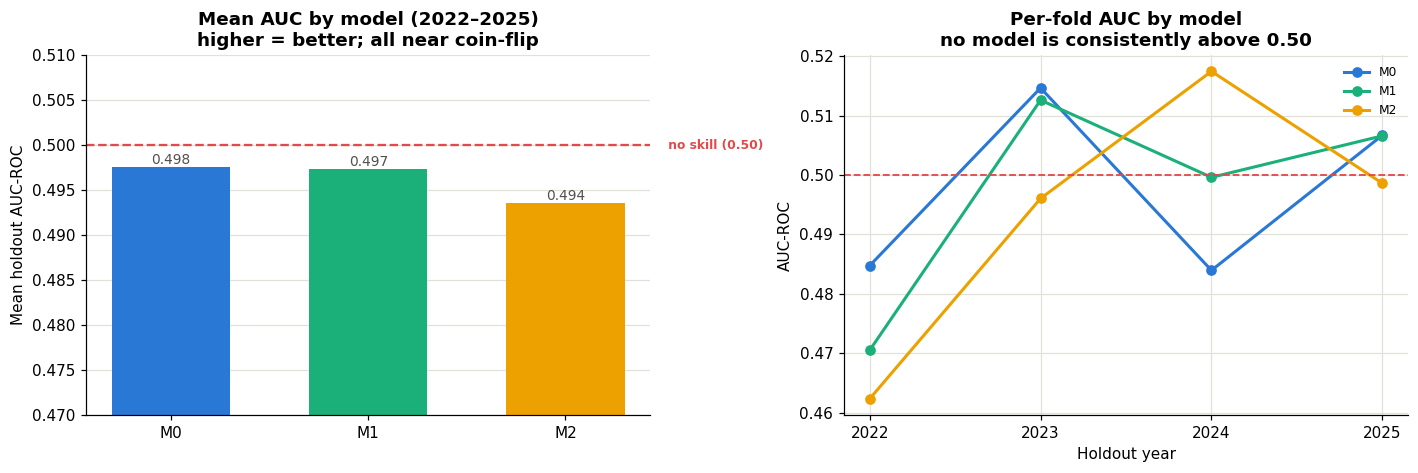

Saved model_outputs/finbert_model_comparison.png


In [7]:
C = {"M0 Market only": "#2a78d6", "M1 Market + RavenPack": "#1baf7a",
     "M2 Market + FinBERT": "#eda100", REFERENCE: "#898781"}
GRID, INK, MUTED = "#e1e0d9", "#0b0b0b", "#52514e"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.titleweight": "bold", "figure.dpi": 110})

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

ax = axes[0]
models_only = list(MODELS)
vals = comparison.loc[models_only, "AUC (mean folds)"]
bars = ax.bar(range(len(models_only)), vals.values, color=[C[m] for m in models_only], width=0.6)
ax.axhline(0.5, color="#e34948", lw=1.5, ls="--")
ax.text(len(models_only) - 0.5, 0.5, " no skill (0.50)", color="#e34948", va="center", fontsize=8, fontweight="bold")
for i, v in enumerate(vals.values):
    ax.text(i, v, f"{v:.3f}", ha="center", va="bottom", fontsize=9, color=MUTED)
ax.set_xticks(range(len(models_only)), [m.split(" ", 1)[0] for m in models_only])
ax.set_ylim(min(0.47, vals.min() - 0.01), max(0.51, vals.max() + 0.01))
ax.set_ylabel("Mean holdout AUC-ROC")
ax.set_title("Mean AUC by model (2022–2025)\nhigher = better; all near coin-flip")
ax.grid(axis="y", color=GRID); ax.set_axisbelow(True)

ax = axes[1]
fold_auc = metrics_df.loc[metrics_df["metric"] == "auc_roc"].pivot(index="fold", columns="model", values="score")
for m in models_only:
    ax.plot(fold_auc.index, fold_auc[m], marker="o", color=C[m], lw=2, label=m.split(" ", 1)[0])
ax.axhline(0.5, color="#e34948", lw=1.2, ls="--")
ax.set_xticks(TEST_YEARS)
ax.set_xlabel("Holdout year"); ax.set_ylabel("AUC-ROC")
ax.set_title("Per-fold AUC by model\nno model is consistently above 0.50")
ax.legend(frameon=False, fontsize=8); ax.grid(color=GRID); ax.set_axisbelow(True)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "finbert_model_comparison.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved model_outputs/finbert_model_comparison.png")

### Handoff

- **`data_collection/finbert_daily_df.csv`** — reusable session-level FinBERT aggregate (safe to commit). Consumed by notebook 10 (M3).
- **`model_outputs/finbert_walk_forward_metrics.csv`**, **`finbert_holdout_predictions.csv`**, **`model_comparison_m0_m2.csv`**, **`finbert_model_comparison.png`** — M0/M1/M2 results.
- **Finding:** FinBERT sentiment (M2) does not improve daily direction prediction over market-only, and does not beat RavenPack (M1). Both sentiment signals are null at this horizon.
- **Next:** notebook 10 combines RavenPack + FinBERT (M3) in the same harness; later, Christian evaluates an Autoformer on the LLM sentiment matrix — a higher-capacity sequence model that may extract structure this linear daily classifier cannot.